In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

- Create a true population with infections, get a biased sample from it
- The biased sample represents the data we would get from an actual study
- From the true population, we pretend to know only the distribution of the covariates
- Hence, we can create an approximation of the true population by stratified sampling from the biased sample

In [ ]:
# Define the true population
def generate_true_population(size: int, seed: int = None) -> pd.DataFrame:
    # generator
    rnd = np.random.default_rng(seed=seed)
    
    # Distribution of gender, age groups, and urban/rural location
    gender = rnd.choice(['male', 'female'], size=size)
    age_group = rnd.choice(['0-18', '19-35', '36-60', '61+'], size=size, p=[0.2, 0.3, 0.3, 0.2])
    location = rnd.choice(['urban', 'rural'], size=size, p=[0.6, 0.4]) 

    # Baseline infectiousness and relative age-dependent infectiousness
    baseline_infectiousness = np.log(0.05)
    relative_infectiousness = {'0-18': 1., '19-35': np.log(1.0), '36-60':np.log(1.5), '61+': np.log(2.0)}
    urban_infectiousness_multiplier = 1.3  # 30% higher risk in urban areas
    
    # Adjust infectiousness based on location (higher in urban areas)
    # Calculate infections based on age group and location
    # Calculate log-odds of infection based on age and location
    log_odds = (baseline_infectiousness + 
                np.array([relative_infectiousness[age] for age in age_group]) +
                urban_infectiousness_multiplier * np.array([1. if loc == 'urban' else 0. for loc in location]))
    infection_prob = 1. / (1. + np.exp(-log_odds))
    
    # Generate infections based on calculated probabilities
    infections = rnd.uniform(size=size) < infection_prob
    
    # Create a DataFrame for the population
    return pd.DataFrame({
        'gender': gender,
        'age_group': age_group,
        'location': location,
        'infected': infections
    })

true_population = generate_true_population(size=10000, seed=42)

In [ ]:
# generate a full population from a biased sample
def generate_population_from_sample(biased_sample: pd.DataFrame, seed: int = None) -> pd.DataFrame:
    # Generate a population DataFrame based on the sample
    # Calculate weights
    biased_sample['weight'] = calculate_weights(biased_sample, true_population, covariates=['age_group', 'gender', 'location'])

    # Generate a population DataFrame based on the sample
    population = true_population.sample(
        n=true_population.shape[0],
        replace=True,
        weights=biased_sample['weight'],
        random_state=seed
    )
    return population

# generate a biased sample from a full population
def sample_population(
        full_population: pd.DataFrame,
        sample_size: int,
        urban_overrepresented: bool = False,
        seed: int = None
) -> pd.DataFrame:
    if urban_overrepresented:
        # Over-represent urban individuals
        urban_sample = full_population[full_population['location'] == 'urban'].sample(frac=0.9, replace=False, random_state=seed)
        rural_sample = full_population[full_population['location'] == 'rural'].sample(frac=0.1, replace=False, random_state=seed)
        new_sample = pd.concat([urban_sample, rural_sample]).sample(n=sample_size, replace=False, random_state=seed)
    else:
        # Random sample
        new_sample = full_population.sample(n=sample_size, replace=False, random_state=seed)
    return new_sample

true_biased_sample = sample_population(true_population, sample_size=200, urban_overrepresented=True, seed=42)
true_random_sample = sample_population(true_population, sample_size=200, urban_overrepresented=False, seed=42)

In [ ]:
# calculate the prevalence of the population
def calculate_prevalence(sample: pd.DataFrame) -> float:
    return sample['infected'].mean()


def calculate_weights(sample: pd.DataFrame, full_population: pd.DataFrame, covariates: list) -> np.ndarray:
    # Calculate population distribution for all covariate combinations
    full_population_distribution = full_population.groupby(covariates).size() / len(full_population)
    
    # Calculate sample distribution for all covariate combinations
    sample_distribution = sample.groupby(covariates).size() / len(sample)
    
    # Initialize a column for weights
    weights = pd.Series(np.zeros(len(sample)), index=sample.index)
    
    # Iterate over all unique covariate combinations
    for covariate_values, full_population_ratio in full_population_distribution.items():
        sample_ratio = sample_distribution.get(covariate_values, 0)
        
        # Calculate weight
        weight = full_population_ratio / sample_ratio if sample_ratio > 0 else 0
        
        # Assign weight to the corresponding rows in the sample
        condition = (sample[list(covariates)] == pd.Series(covariate_values, index=covariates)).all(axis=1)
        weights.loc[condition] = weight

    return weights
    

def calculate_weighted_prevalence(sample: pd.DataFrame, full_population: pd.DataFrame) -> float:
    # Calculate weights
    sample['weight'] = calculate_weights(sample, full_population, covariates=['age_group', 'gender', 'location'])

    # Calculate weighted prevalence
    return np.average(sample['infected'], weights=sample['weight'])


weighted_prevalence = calculate_weighted_prevalence(true_biased_sample, true_population)
_ = calculate_weighted_prevalence(true_random_sample, true_population)

In [ ]:
# visualize the results
def visualize_results(full_population: pd.DataFrame, 
                      random_sample: pd.DataFrame, biased_sample: pd.DataFrame, 
                      weighted_prevalence: float):
    # Calculate prevalences
    true_prevalence = calculate_prevalence(full_population)
    random_prevalence = calculate_prevalence(random_sample)
    biased_prevalence = calculate_prevalence(biased_sample)

    # Create visualization
    labels = ['True Prevalence', 'Random Sample', 'Biased Sample', 'Weighted Biased Sample']
    prevalences = [true_prevalence, random_prevalence, biased_prevalence, weighted_prevalence]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, prevalences, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.ylabel('Prevalence')
    plt.ylim(0, max(prevalences) + 0.05)
    plt.title('Prevalence Comparison')
    plt.show()
    
visualize_results(true_population, true_random_sample, true_biased_sample, weighted_prevalence)

In [ ]:
# create a new data set (parameters are fixed, true prevalence should not change too much)
# analyse the effect of the biased sampling on estimation of the true prevalence

n_rounds = 100
true_prevalence = np.zeros(n_rounds)
sampled_prevalence = np.zeros(n_rounds)
sampled_prevalence_biased = np.zeros(n_rounds)
sampled_prevalence_weighted = np.zeros(n_rounds)
for i in range(n_rounds):
    _population = generate_true_population(size=10000)
    _random_sample = sample_population(_population, sample_size=200, urban_overrepresented=False)
    _biased_sample = sample_population(_population, sample_size=200, urban_overrepresented=True)
    
    true_prevalence[i] = calculate_prevalence(_population)
    sampled_prevalence[i] = calculate_prevalence(_random_sample)
    sampled_prevalence_biased[i] = calculate_prevalence(_biased_sample)
    sampled_prevalence_weighted[i] = calculate_weighted_prevalence(_biased_sample, _population)
    
plt.figure(figsize=(7, 4))
labels = ['True Prevalence', 'Random Sample', 'Biased Sample', 'Weighted Sample']
for i, p in enumerate([true_prevalence, sampled_prevalence, sampled_prevalence_biased, sampled_prevalence_weighted]):
    plt.errorbar(labels[i], [np.median(p)], [np.std(p)], fmt='o')
plt.ylabel('Prevalence')
plt.title('Prevalence Comparison')
plt.show()

## Prevalence Estimation with NPE

In [ ]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [ ]:
param_names = ['prevalance']
param_names

In [ ]:
def convert_to_nn_input(df: pd.DataFrame) -> np.ndarray:
    df_temp = df.copy()
    # convert to neural network input
    if 'weight' in df_temp.columns:
        df_temp.drop(columns=['weight'], inplace=True)
    df_temp = pd.get_dummies(df_temp, columns=['gender', 'age_group', 'location'], drop_first=True)
    # convert true/false into 0/1
    df_temp = df_temp.astype(int)
    return df_temp[['infected', 'gender_male', 'age_group_19-35', 'age_group_36-60', 'age_group_61+', 'location_urban']].values

In [ ]:
def generative_model(
        batch_size: int, 
        sample_size: int = 200,
        urban_overrepresented: bool = True,
        output: str = 'true', 
        seed: bool = False
) -> dict:
    # generate data and parameters
    data = np.zeros((batch_size, sample_size, 6), dtype=np.float32)
    param_batch = np.zeros((batch_size, 1), dtype=np.float32)

    for i in range(batch_size):
        # generate a new full population from the true biased sample (the data we would get from the survey)
        new_population = generate_population_from_sample(
            biased_sample=true_biased_sample,
            seed=i if seed is True else None
        )
        # now draw a new biased sample from the population
        new_biased_sample = sample_population(
            full_population=new_population,
            sample_size=sample_size,
            urban_overrepresented=urban_overrepresented,
            seed=i if seed is True else None
        )
        if output == 'true':
            new_prevalence = calculate_prevalence(sample=new_population)
        elif output == 'weighted':
            new_prevalence = calculate_weighted_prevalence(sample=new_biased_sample, full_population=true_population)
        elif output == 'biased':
            new_prevalence = calculate_prevalence(sample=new_biased_sample)
        else:
            raise ValueError('Output must be one of "true", "weighted", or "biased"')
        
        # save the data and parameters
        param_batch[i] = np.log(new_prevalence)
        data[i] = convert_to_nn_input(new_biased_sample)
    return {'sim_data': data, 'prior_draws': param_batch}

In [130]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    #permutation="learnable"
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [ ]:
np.random.seed(42)
_prior_draws = generative_model(1000)['prior_draws']
prior_mean = _prior_draws.mean(axis=0)
prior_std = _prior_draws.std(axis=0)

In [ ]:
plt.hist(np.exp(_prior_draws), bins=30, alpha=0.5, label='Prior Draws')
plt.axvline(np.exp(prior_mean), color='r', label='Prior Mean')
plt.legend()
plt.show()

In [ ]:
def configurator(forward_dict: dict) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"]
    out_dict['summary_conditions'] = x.astype(np.float32)

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [131]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [ ]:
%%time
offline_data = generative_model(1000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

In [132]:
history = trainer.train_offline(
    simulations_dict=offline_data,
    epochs=10,
    batch_size=128,
    early_stopping=True,
    validation_sims=valid_data
)

Training epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 1.402


Training epoch 2:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 1.402


Training epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 5, Loss: 1.402


Training epoch 6:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 6, Loss: 1.402


Training epoch 7:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 7, Loss: 1.402
INFO:root:Early stopping triggered.


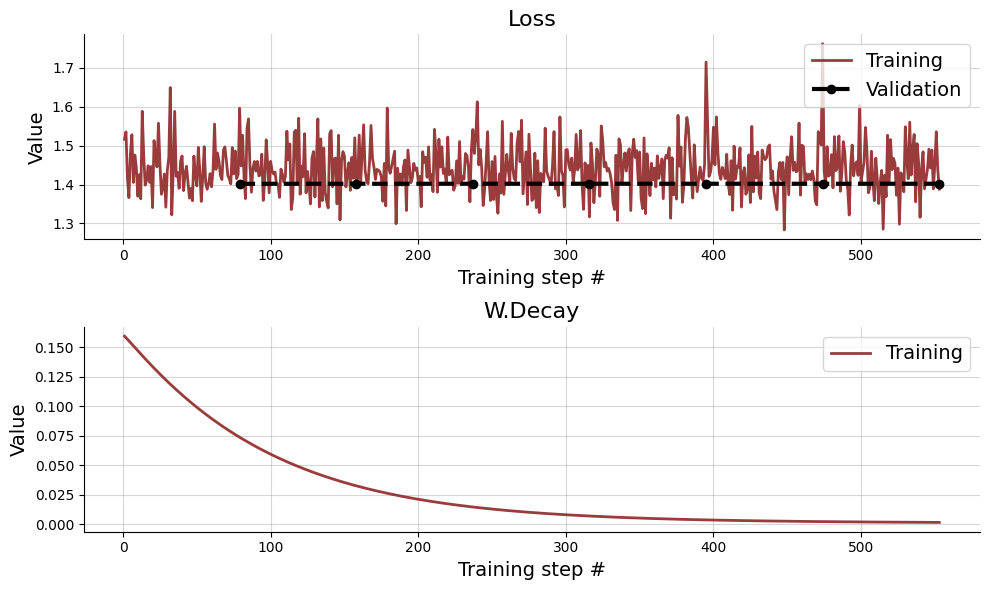

In [133]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [134]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

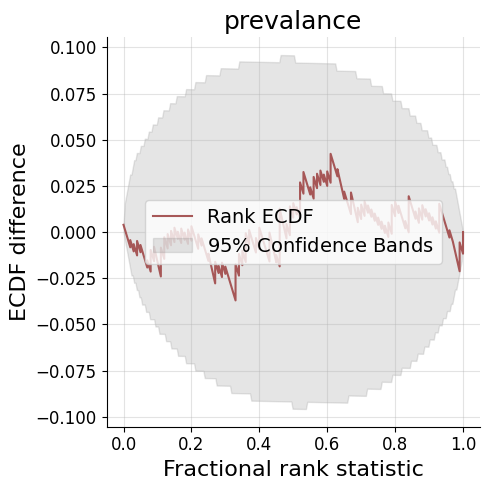

In [135]:
bf.diagnostics.plot_sbc_ecdf(np.exp(posterior_samples), np.exp(prior_draws), difference=True, param_names=param_names);

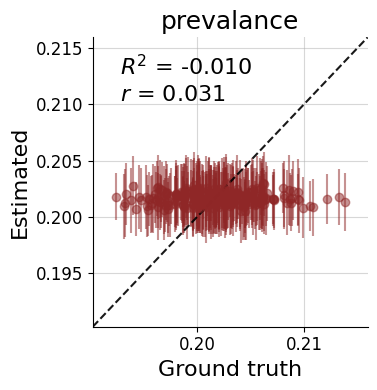

In [136]:
bf.diagnostics.plot_recovery(np.exp(posterior_samples), np.exp(prior_draws), param_names=param_names);

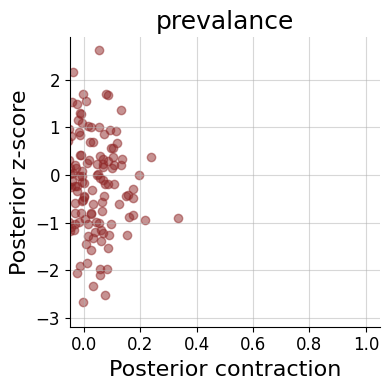

In [137]:
bf.diagnostics.plot_z_score_contraction(np.exp(posterior_samples), np.exp(prior_draws), param_names=param_names);

## Prevalence Estimation with NPE

In [138]:
true_prevalence = calculate_prevalence(true_population)
biased_prevalence = calculate_prevalence(true_biased_sample)
random_prevalence = calculate_prevalence(true_random_sample)

Biased


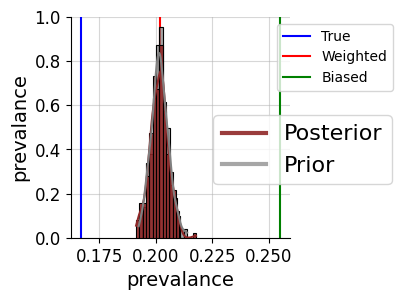

Random


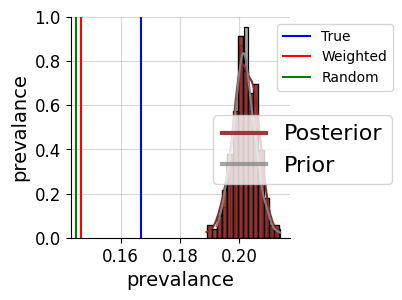

In [139]:
for sample, sample_name, p in zip([true_biased_sample, true_random_sample], ['Biased', 'Random'], [biased_prevalence, random_prevalence]):
    print(sample_name)
    weighted_prevalence = calculate_weighted_prevalence(sample, true_population)
    
    test_data = {'sim_data': convert_to_nn_input(sample)[np.newaxis]}
    posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=prior_draws.shape[0])
    posterior_samples = posterior_samples * prior_std + prior_mean
    
    fig = bf.diagnostics.plot_posterior_2d(
        posterior_draws=np.exp(posterior_samples),
        prior_draws=np.exp(prior_draws),
        param_names=[param_names[0]]
    )
    # add the true parameters
    ax = fig.get_axes()
    j = 0
    for i, a in enumerate(ax):
        # plot only on the diagonal
        if i == i // len(param_names) * (len(param_names)+1):
            a.axvline(true_prevalence, color='b', label='True')
            a.axvline(weighted_prevalence, color='r', label='Weighted')
            a.axvline(p, color='g', label=sample_name)
            #a.axvline(random_prevalence, color='y', label='Random')
            #print(logistic_params)
            #a.axvline(np.exp(true_params[param_names[j]]), color='b', label='True')
            #a.axvline(logistic_params[2], color='r', label='Logistic Weighted')
            #a.axvline(logistic_params[1], color='g', label='Logistic')
            a.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
            j += 1
    plt.show()

biased


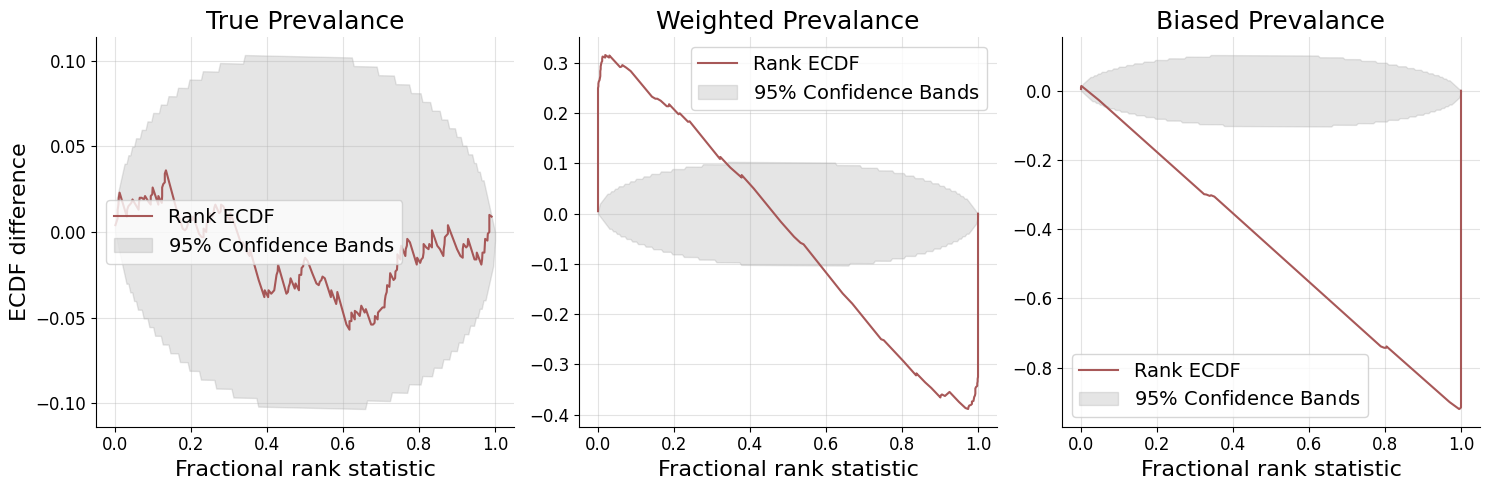

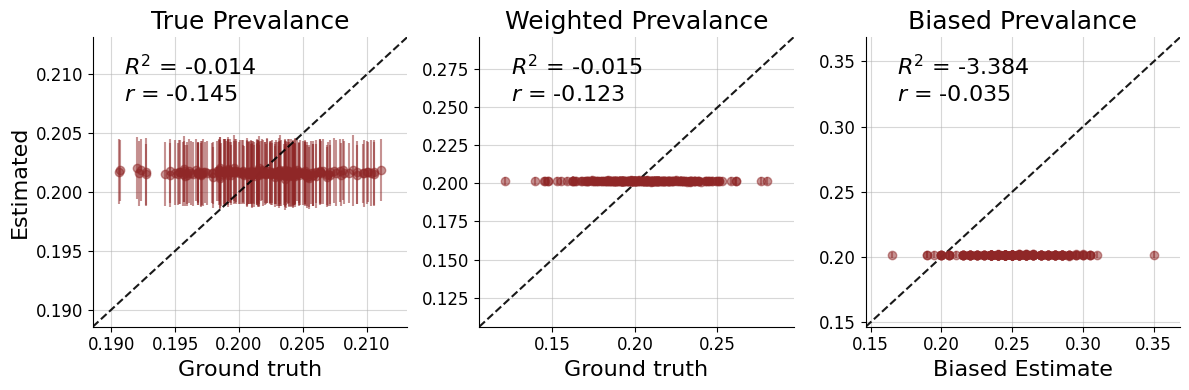

random


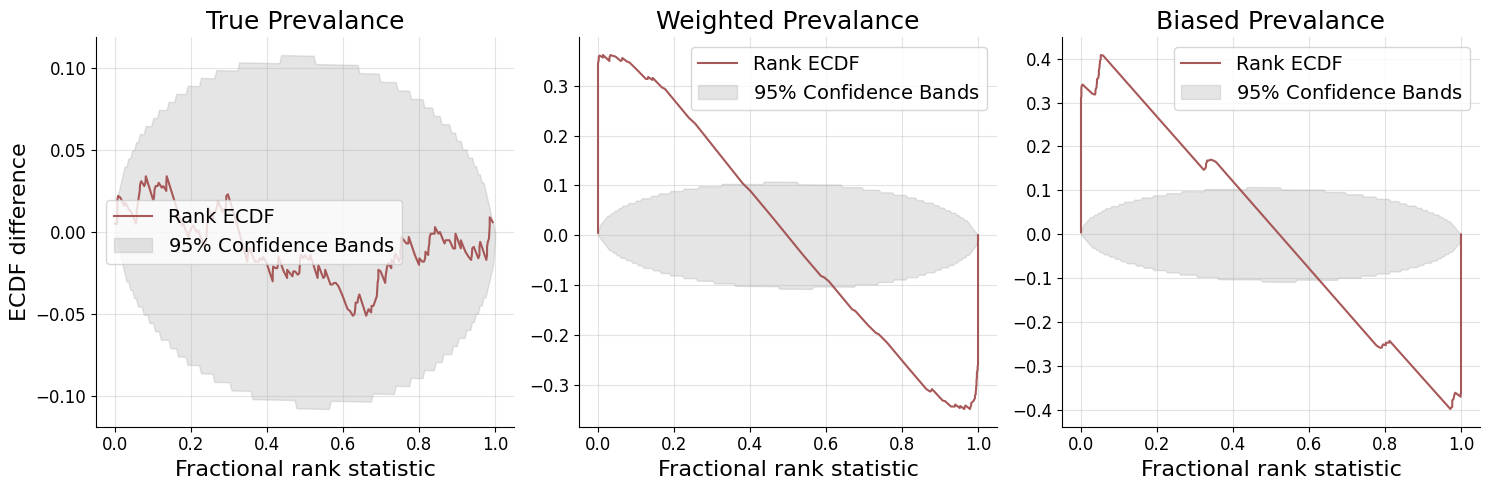

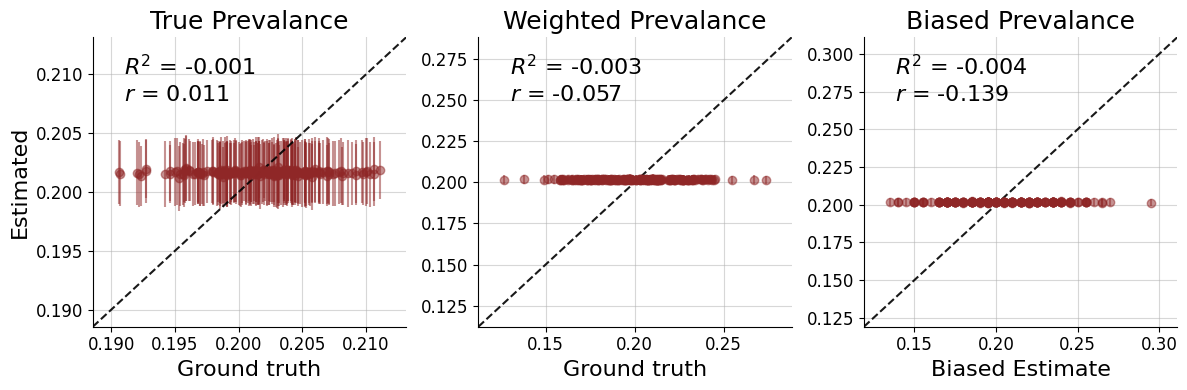

In [140]:
combined_names = ['True Prevalance', 'Weighted Prevalance', 'Biased Prevalance']
for overrepresented, sample_name in zip([True, False], ['biased', 'random']):
    print(sample_name)
    
    test_data = generative_model(200, sample_size=200, urban_overrepresented=overrepresented, seed=True)
    test_data_weighted = generative_model(200, sample_size=200, urban_overrepresented=overrepresented, output='weighted', seed=True)
    test_data_biased = generative_model(200, sample_size=200, urban_overrepresented=overrepresented, output='biased', seed=True)
    test_params = test_data['prior_draws']
    test_params_weighted = test_data_weighted['prior_draws']
    test_params_biased = test_data_biased['prior_draws']
    assert np.all(test_data['sim_data'] == test_data_weighted['sim_data'])
    assert np.all(test_data['sim_data'] == test_data_biased['sim_data'])
    
    posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)
    posterior_samples = posterior_samples * prior_std + prior_mean
    
    posterior_samples = np.concatenate((posterior_samples, posterior_samples, posterior_samples), axis=-1)
    test_params = np.concatenate((test_params, test_params_weighted, test_params_biased), axis=-1)
    posterior_samples = np.exp(posterior_samples)
    test_params = np.exp(test_params)
    t = test_params[:, 1] < 0.4
    test_params = test_params[t]
    posterior_samples = posterior_samples[t]
    
    bf.diagnostics.plot_sbc_ecdf(posterior_samples, test_params, difference=True, param_names=combined_names)
    fig = bf.diagnostics.plot_recovery(posterior_samples, test_params, param_names=combined_names)
    ax = fig.get_axes()
    ax[-1].set_xlabel('Weighted Estimate')
    ax[-1].set_xlabel('Biased Estimate')
    plt.show()